In [7]:
# --- Radar (polar) plot of network-level ΔFC ---
# Data requirements:
# df_net columns: ['subject','condition','window','network','delta_fc']
# optional df_stats columns: ['network','window','p','q'] for FDR stars

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import scipy
from scipy import stats
from nilearn import input_data, datasets, plotting, signal
from statsmodels.stats.multitest import multipletests

In [8]:
## Load the precomputed dataframe
path_to_df = '../data/precomputed/df_fc.pkl'
df = pd.read_pickle(path_to_df)

difumo = datasets.fetch_atlas_difumo(dimension=1024)
df_labels = pd.DataFrame(difumo.labels)  # List of 1024 anatomical labels
#atlas_img = nib.load(difumo.maps)
subgenual = df_labels.loc[133,'difumo_names']

df_labels["yeo_networks7"].unique()
yeo_map = {roi : network for roi, network in zip(df_labels["difumo_names"], df_labels["yeo_networks7"])}

df["is_roi1_subgenual"] = df["roi1"] == subgenual
df["is_roi2_subgenual"] = df["roi2"] == subgenual
df["is_pair_subgenual"] = df["is_roi1_subgenual"] | df["is_roi2_subgenual"]
df_sg = df[df["is_pair_subgenual"]].copy()
df_sg["roi_pair"] = ["__".join(sorted((r1, r2))) for r1, r2 in zip(df_sg["roi1"], df_sg["roi2"])]

df_sg["network1"] = df_sg["roi1"].map(yeo_map)
df_sg["network2"] = df_sg["roi2"].map(yeo_map)
df_sg["network_pair"] = ["__".join(sorted((n1, n2))) for n1, n2 in zip(df_sg["network1"], df_sg["network2"])]

# remove entries without a Yeo-7 assignment for either ROI
df_sg = df_sg[~df_sg["network_pair"].str.contains("No network found", na=False)].copy()

def _extract_partner_network(pair):
    tokens = pair.split("__")
    partners = [token for token in tokens if not token.startswith("Limbic")]
    if not partners:
        partners = [tokens[0]]
    return partners[0]

network_label_map = {
    "Vis": "Visual",
    "Cont": "Control",
    "Default": "Default Mode",
    "DorsAttn": "Dorsal Attention",
    "Limbic": "Limbic",
    "SalVentAttn": "Salience",
    "SomMot": "Somatomotor",
}

def _format_network_label(network_code):
    if network_code is None:
        return None
    base = network_code.rstrip("AB")
    if base.startswith("Vis"):
        base = "Vis"
    return network_label_map.get(base, base)

df_sg["network_partner"] = df_sg["network_pair"].apply(_extract_partner_network)
df_sg["network_label"] = df_sg["network_partner"].apply(_format_network_label)
allowed_networks = list(network_label_map.values())
df_sg = df_sg[df_sg["network_label"].isin(allowed_networks)].copy()
df_sg.head()

dfw = df_sg.copy().drop(columns=["roi1", "roi2", "is_roi1_subgenual", "is_roi2_subgenual", "is_pair_subgenual",
                                  "roi_pair", "network1", "network2"]).reset_index(drop=True)

# baseline at the subject × (sgACC-network) × condition level
dfw["subject_network_condition"] = list(zip(dfw["subject"], dfw["network_pair"], dfw["condition"]))
baseline_lookup = (
    dfw[dfw["time_window"] == "pre"]
    .set_index("subject_network_condition")["fc"]
    .to_dict()
)

dfw["baseline_fc"] = dfw["subject_network_condition"].map(baseline_lookup)
dfw = dfw.dropna(subset=["baseline_fc"]).reset_index(drop=True)
dfw["delta_fc"] = dfw["fc"] - dfw["baseline_fc"]
dfw.drop(columns=["subject_network_condition"], inplace=True)
dfw.head()

df_delta = dfw[dfw["time_window"] != "pre"].copy()
#df_delta = dfw.copy()
group_cols = ["subject", "condition", "time_window", "network_label"]
df_subject_delta = (
    df_delta
    .groupby(group_cols, as_index=False)["delta_fc"]
    .mean()
)

time_order = ["fus", "post"]
network_order = ["Visual", "Control", "Default Mode", "Dorsal Attention", "Limbic", "Salience", "Somatomotor"]

df_subject_delta["time_window"] = pd.Categorical(
    df_subject_delta["time_window"],
    categories=time_order,
    ordered=True
)

df_subject_delta["network_label"] = pd.Categorical(
    df_subject_delta["network_label"],
    categories=network_order,
    ordered=True
)

dfr = (
    df_subject_delta
    .groupby(["network_label", "condition", "time_window"], as_index=False)["delta_fc"]
    .mean()
)

/var/folders/g9/8jw7l6116kdd4pc549qnnz8r0000gn/T/ipykernel_9424/520162815.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["network_label", "condition", "time_window"], as_index=False)["delta_fc"]


In [9]:
test_records = []

for network in network_order:
    for time_window in time_order:
        sham_vals = df_subject_delta[
            (df_subject_delta["condition"] == "sham")
            & (df_subject_delta["network_label"] == network)
            & (df_subject_delta["time_window"] == time_window)
        ]["delta_fc"].dropna()

        active_vals = df_subject_delta[
            (df_subject_delta["condition"] == "active")
            & (df_subject_delta["network_label"] == network)
            & (df_subject_delta["time_window"] == time_window)
        ]["delta_fc"].dropna()

        if len(sham_vals) < 2 or len(active_vals) < 2:
            t_stat, p_val = float('nan'), float('nan')
        else:
            t_stat, p_val = stats.ttest_ind(active_vals, sham_vals, equal_var=False, method = scipy.stats.PermutationMethod(), alternative = 'greater')

        test_records.append({
            "network": network,
            "time_window": time_window,
            "n_sham": len(sham_vals),
            "n_active": len(active_vals),
            "t_stat": t_stat,
            "p_value": p_val,
        })

test_df = pd.DataFrame(test_records)
mask = test_df["p_value"].notna()
if mask.any():
    _, p_fdr, _, _ = multipletests(test_df.loc[mask, "p_value"], method="fdr_bh")
    test_df.loc[mask, "p_fdr"] = p_fdr


In [10]:
df_subject_delta.rename(columns={'time_window':'window', 'network_label': 'network'}, inplace=True)
test_df.rename(columns={'time_window':'window', 'network_label': 'network'}, inplace=True)
test_df.rename(columns={'p_value':'p', 'p_fdr':'q'}, inplace=True)

df_net = df_subject_delta.copy()
df_stats = test_df.copy()

In [27]:
df_stats

,network,window,n_sham,n_active,t_stat,p,q
0,Visual,fus,16,16,0.884292,0.1874,0.218633
1,Visual,post,16,16,1.129052,0.1317,0.193060
2,Control,fus,16,16,3.138767,0.0024,0.028000
3,Control,post,16,16,2.859692,0.0040,0.028000
4,Default Mode,fus,16,16,-0.960781,0.8343,0.834300
5,Default Mode,post,16,16,-0.722440,0.7646,0.823415
6,Dorsal Attention,fus,16,16,1.035756,0.1554,0.197782
7,Dorsal Attention,post,16,16,1.103197,0.1379,0.193060
8,Limbic,fus,16,16,1.345220,0.0932,0.163100
9,Limbic,post,16,16,1.444697,0.0779,0.163100


/var/folders/g9/8jw7l6116kdd4pc549qnnz8r0000gn/T/ipykernel_9424/2473643069.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['condition','window','network'], as_index=False)
/var/folders/g9/8jw7l6116kdd4pc549qnnz8r0000gn/T/ipykernel_9424/2473643069.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({'mean': bootstrap_ci(g['delta_fc'])[0],


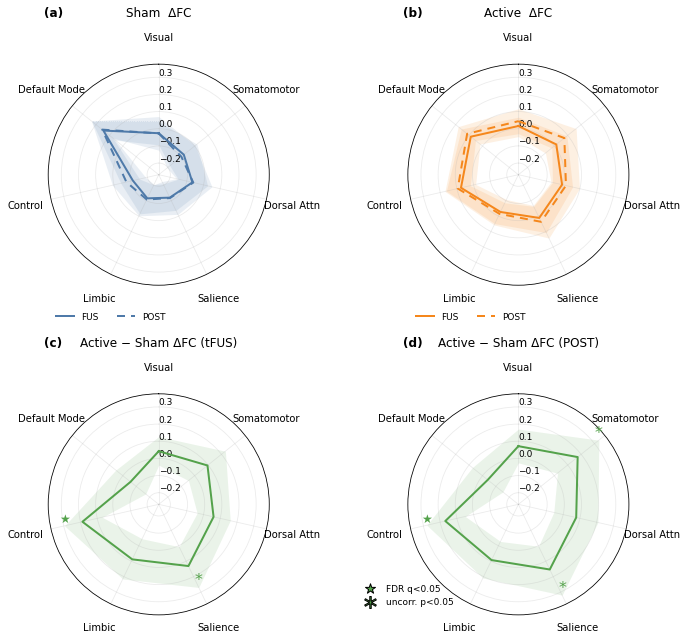

In [26]:


## WORKING VERSION

# ===== Radar (polar) plot of network-level ΔFC with significance stars =====
# Expects:
#   df_net: columns ['subject','condition','window','network','delta_fc']
#   optional df_stats: ['network','window','p','q']  (FDR-adjusted q-values per network × window)
# ----------------------------------------------------------------------------



# ---------------- CONFIG ----------------
networks  = ['Visual','Somatomotor','Dorsal Attention','Salience','Limbic','Control','Default Mode']
display_labels = ['Visual','Somatomotor','Dorsal Attn','Salience','Limbic','Control','Default Mode']
win_order = ['fus','post']                            # windows available
win_title = {'fus':'tFUS', 'post':'POST'}
cond_colors = {'sham': '#4C78A8', 'active': '#F58518'}
diff_color  = '#54A24B'
ci_alpha    = 0.12
line_alpha  = 0.98
lw          = 2.
STAR_Q      = 0.05         # FDR threshold for asterisks
STAR_P      = 0.05         # uncorrected p threshold for asterisks
show_stars  = True          # turn on/off star annotation if df_stats is available
theta_label_pad = 16          # pad theta tick labels outward (points)
# ----------------------------------------

def bootstrap_ci(x, n_boot=4000, ci=95, rng=None):
    x = pd.Series(x).dropna().values
    if x.size == 0:
        return np.nan, (np.nan, np.nan)
    rng = np.random.default_rng() if rng is None else rng
    boots = rng.choice(x, size=(n_boot, x.size), replace=True).mean(axis=1)
    return x.mean(), (np.percentile(boots, 50-ci/2), np.percentile(boots, 50+ci/2))

# 1) Aggregate ΔFC means and CIs per (condition, window, network)
agg = (df_net
       .groupby(['condition','window','network'], as_index=False)
       .apply(lambda g: pd.Series({'mean': bootstrap_ci(g['delta_fc'])[0],
                                   'ci_lo': bootstrap_ci(g['delta_fc'])[1][0],
                                   'ci_hi': bootstrap_ci(g['delta_fc'])[1][1]}))
       .reset_index(drop=True))

# 2) Paired Active−Sham difference (per window, network) with bootstrap CI
def paired_diff(window):
    rows = []
    for net in networks:
        wide = (df_net[(df_net['window'].eq(window)) & (df_net['network'].eq(net))]
                .pivot_table(index='subject', columns='condition', values='delta_fc'))
        if {'active','sham'}.issubset(wide.columns):
            diffs = (wide['active'] - wide['sham']).dropna().values
            m, (lo, hi) = bootstrap_ci(diffs)
        else:
            # fallback (unlikely): mean(active) - mean(sham)
            a = df_net[(df_net['window'].eq(window)) & (df_net['network'].eq(net)) & (df_net['condition'].eq('active'))]['delta_fc']
            s = df_net[(df_net['window'].eq(window)) & (df_net['network'].eq(net)) & (df_net['condition'].eq('sham'))]['delta_fc']
            m = a.mean() - s.mean()
            lo, hi = np.nan, np.nan
        rows.append({'window': window, 'network': net, 'mean': m, 'ci_lo': lo, 'ci_hi': hi})
    return pd.DataFrame(rows)

diff_df = pd.concat([paired_diff(w) for w in win_order], ignore_index=True)

# 3) Polar geometry
angles   = np.linspace(0, 2*np.pi, len(networks), endpoint=False)
angles_c = np.r_[angles, angles[0]]  # close polygon

def _vals(df_slice):
    arr = df_slice.set_index('network').loc[networks, 'mean'].values
    return np.r_[arr, arr[0]]

def _cis(df_slice):
    lo = df_slice.set_index('network').loc[networks, 'ci_lo'].values
    hi = df_slice.set_index('network').loc[networks, 'ci_hi'].values
    return np.r_[lo, lo[0]], np.r_[hi, hi[0]]

def _global_ylim():
    """Shared polar radii across all panels (includes CI bounds)."""
    stacks = []
    # condition panels
    for cond in ['sham','active']:
        for w in win_order:
            sl = agg[(agg['condition'].eq(cond)) & (agg['window'].eq(w))]
            y = _vals(sl)
            lo, hi = _cis(sl)
            stacks.append(np.c_[y, lo, hi].ravel())
    # diff panels
    for w in win_order:
        sl = diff_df[diff_df['window'].eq(w)]
        y = _vals(sl)
        lo, hi = _cis(sl)
        stacks.append(np.c_[y, lo, hi].ravel())
    finite = np.concatenate([s[np.isfinite(s)] for s in stacks if s.size])
    if finite.size == 0:
        return (0, 1)
    rmin = min(0.0, float(np.nanmin(finite)))
    rmax = float(np.nanmax(finite))
    pad  = 0.08* (rmax - rmin if rmax > rmin else 1.0)
    return (rmin - pad, rmax + pad)

global_ylim = _global_ylim()


def _style(ax, title):
    ax.set_theta_offset(np.pi/2)           # start at top
    ax.set_theta_direction(-1)             # clockwise
    ax.set_thetagrids(np.degrees(angles), labels=display_labels, fontsize=10)
    ax.set_title(title, pad=16, fontsize=12, fontweight='normal')
    ax.grid(True, alpha=0.25)
    ax.set_rlabel_position(0)
    ax.tick_params(axis='x', pad=theta_label_pad)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_ylim(*global_ylim)

# 4) Star/asterisk annotation helper
def annotate_stars(ax, df_slice, window_label, color):
    if not (show_stars and 'df_stats' in globals() and isinstance(df_stats, pd.DataFrame)):
        return []
    # Compute per-axis max to place markers just above data
    y_means = _vals(df_slice)
    _, hi = _cis(df_slice)
    r_max = np.nanmax(np.c_[hi, y_means], axis=1)  # per point
    finite_vals = np.concatenate([y_means[np.isfinite(y_means)], hi[np.isfinite(hi)]])
    if finite_vals.size == 0:
        return []
    r_range = np.nanmax(finite_vals) - np.nanmin(finite_vals)
    margin = 0.0 if r_range == 0 else 0.0 * r_range

    has_star = has_ast = False
    for k, net in enumerate(networks):
        row = df_stats[(df_stats['network'].eq(net)) & (df_stats['window'].eq(window_label))]
        if row.empty or not np.isfinite(r_max[k]):
            continue
        p = row['p'].values[0] if 'p' in row.columns else np.nan
        q = row['q'].values[0] if 'q' in row.columns else np.nan
        if np.isfinite(q) and (q <= STAR_Q):
            ax.text(angles[k], r_max[k] + margin, '★', color=color,
                    ha='center', va='bottom', fontsize=12)
            has_star = True
        elif np.isfinite(p) and (p < STAR_P):
            ax.text(angles[k], r_max[k] + margin, '*', color=color,
                    ha='center', va='bottom', fontsize=16)
            has_ast = True

    handles = []
    if has_star:
        handles.append(Line2D([0],[0], marker=r'$\star$', color='none', markerfacecolor=color,
                              markersize=10, label=f'FDR q<{STAR_Q:.2f}'))
    if has_ast:
        handles.append(Line2D([0],[0], marker=r'$*$', color='none', markerfacecolor=color,
                              markersize=12, label=f'uncorr. p<{STAR_P:.2f}'))
    return handles

# 5) Panels
def panel_condition(ax, condition):
    for w, ls in zip(['fus','post'], ['-', (0,(4,3))]):   # solid=fus, dashed=post
        sl = agg[(agg['condition'].eq(condition)) & (agg['window'].eq(w))]
        y = _vals(sl); lo, hi = _cis(sl)
        col = cond_colors[condition]
        ax.plot(angles_c, y, lw=lw, alpha=line_alpha, color=col, ls=ls, label=w.upper())
        ax.fill_between(angles_c, lo, hi, color=col, alpha=ci_alpha, linewidth=0)
    _style(ax, f'{condition.capitalize()}  ΔFC')

def panel_diff(ax, window_label, title):
    sl = diff_df[diff_df['window'].eq(window_label)]
    y = _vals(sl); lo, hi = _cis(sl)
    ax.plot(angles_c, y, lw=lw, color=diff_color, ls='-', label=window_label.upper())
    ax.fill_between(angles_c, lo, hi, color=diff_color, alpha=ci_alpha, linewidth=0)
    display_window = win_title.get(window_label, window_label.upper())
    _style(ax, f'{title} ({display_window})')
    return annotate_stars(ax, sl, window_label, diff_color)

# 6) Draw 2×2 grid
fig, axs = plt.subplots(2, 2, subplot_kw=dict(polar=True), figsize=(10, 9))

# (a) Sham ΔFC, overlay fus/post
panel_condition(axs[0,0], 'sham')
# (b) Active ΔFC, overlay fus/post
panel_condition(axs[0,1], 'active')
# (c) Active − Sham @ tFUS  **(now tFUS only)**
handles_c = panel_diff(axs[1,0], 'fus', title='Active − Sham ΔFC')
# (d) Active − Sham @ Post
handles_d = panel_diff(axs[1,1], 'post', title='Active − Sham ΔFC')

# Legends for top row
for ax in axs[0,:]:
    ax.legend(loc='lower left', bbox_to_anchor=(0.0,-0.2), ncols=2, frameon=False, fontsize=9)

# Panel c: no legend

# Panel d: only annotation handles (FDR/uncorr.)
legend_d = []
if handles_d:
    legend_d.extend(handles_d)
if legend_d:
    axs[1,1].legend(handles=legend_d, loc='lower left', bbox_to_anchor=(-0.25,-0.00012),
                    frameon=False, fontsize=9)

# Subplot labels
labels = ['(a)','(b)','(c)','(d)']
for ax, lab in zip(axs.flatten(), labels):
    ax.text(-0.02, 1.26, lab, transform=ax.transAxes, ha='left', va='top',
            fontsize=12, fontweight='bold')

plt.tight_layout()
#plt.show()

plt.savefig('../figures/network_level_specificity_polar.png', dpi=300)


[STAR-CHECK] Somatomotor/post in df_stats_use: FOUND → p=0.01420, q=0.06627
[ANNOTATE] * at Salience / fus (p=0.0262, q=0.07728)
[ANNOTATE] ★ at Control / fus (p=0.0024, q=0.028)
[ANNOTATE] * at Somatomotor / post (p=0.0142, q=0.06627)
[ANNOTATE] * at Salience / post (p=0.0276, q=0.07728)
[ANNOTATE] ★ at Control / post (p=0.004, q=0.028)


/var/folders/g9/8jw7l6116kdd4pc549qnnz8r0000gn/T/ipykernel_9424/2551768219.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = (df_net.groupby(['condition','window','network'], as_index=False)
/var/folders/g9/8jw7l6116kdd4pc549qnnz8r0000gn/T/ipykernel_9424/2551768219.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({'mean': bootstrap_ci(g['delta_fc'])[0],


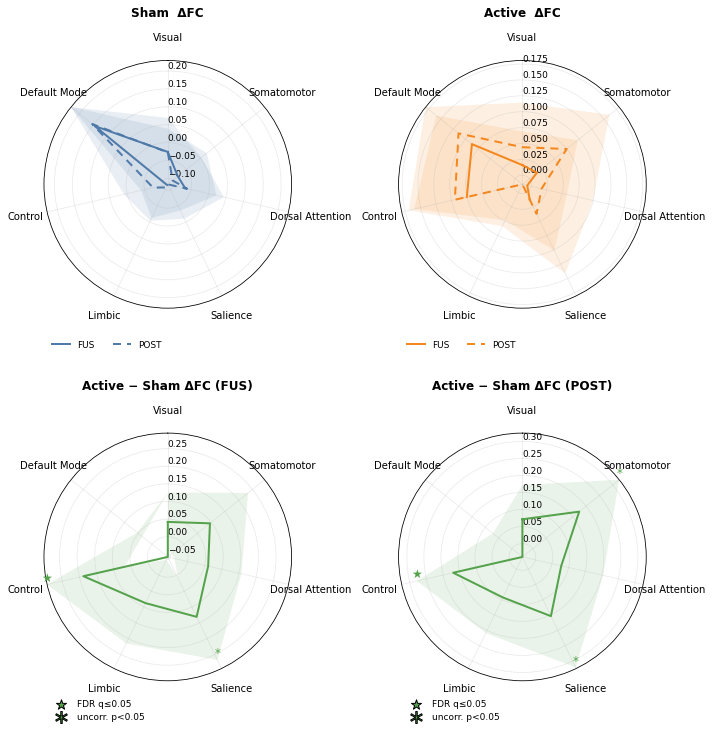

Axes in figure: 4


In [12]:
# ======================= Radar plot with reliable stars/asterisks =======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------- Inputs & checks ----------------
req = {'subject','condition','window','network','delta_fc'}
assert req.issubset(df_net.columns), f"df_net is missing: {req - set(df_net.columns)}"

if 'df_stats' not in globals():
    df_stats = pd.DataFrame(columns=['network','window','p','q'])

# ---------------- Canonical labels & normalization for df_stats ----------------
NETWORKS = ['Visual','Somatomotor','Dorsal Attention','Salience','Limbic','Control','Default Mode']
WINDOWS  = ['fus','post']  # plot panels use 'fus' and 'post'

CANON_NETWORKS = {
    'visual': 'Visual',
    'somatomotor': 'Somatomotor', 'somato motor': 'Somatomotor', 'somato-motor':'Somatomotor',
    'somatosensory-motor': 'Somatomotor',
    'dorsal attention':'Dorsal Attention',
    'salience':'Salience',
    'limbic':'Limbic',
    'control':'Control', 'cognitive control':'Control',
    'default mode network':'Default Mode','default-mode':'Default Mode','default mode':'Default Mode','dmn':'Default Mode',
}
CANON_WINDOWS = {
    'baseline':'pre','pre':'pre',
    't_fus':'fus','t-fus':'fus','tfus':'fus','fus':'fus',
    'post':'post','post-tfus':'post','post_tfus':'post','post-t_fus':'post'
}
def canon_net(x):
    key = str(x).strip().lower()
    return CANON_NETWORKS.get(key, str(x).strip())
def canon_win(x):
    key = str(x).strip().lower()
    return CANON_WINDOWS.get(key, str(x).strip().lower())

_stats = df_stats.copy()
if not _stats.empty:
    _stats['network'] = _stats['network'].apply(canon_net)
    _stats['window']  = _stats['window'].apply(canon_win)
    for col in ['p','q']:
        if col not in _stats.columns:
            _stats[col] = np.nan
        else:
            _stats[col] = pd.to_numeric(_stats[col], errors='coerce')
    # collapse duplicates: take min p and min q per (network, window)
    df_stats_use = (_stats.groupby(['network','window'], as_index=False)
                           .agg(p=('p','min'), q=('q','min')))
else:
    df_stats_use = pd.DataFrame(columns=['network','window','p','q'])

# Quick explicit check for the example you mentioned
_row = df_stats_use[(df_stats_use['network']=='Somatomotor') & (df_stats_use['window']=='post')]
print("[STAR-CHECK] Somatomotor/post in df_stats_use:",
      "FOUND" if not _row.empty else "NOT FOUND",
      ("→ p=%.5f, q=%.5f" % (_row['p'].iloc[0], _row['q'].iloc[0])) if not _row.empty else "")

# ---------------- Config ----------------
cond_colors = {'sham': '#4C78A8', 'active': '#F58518'}
diff_color  = '#54A24B'
ci_alpha    = 0.12
line_alpha  = 0.98
lw          = 2
STAR_Q      = 0.05   # FDR threshold (★)
STAR_P      = 0.05   # uncorrected p threshold (*)
theta_label_pad = 12  # pad theta tick labels (points) to clear the polar circle

# ---------------- Helpers ----------------
def bootstrap_ci(x, n_boot=4000, ci=95, rng=None):
    x = pd.Series(x).dropna().values
    if x.size == 0:
        return np.nan, (np.nan, np.nan)
    rng = np.random.default_rng() if rng is None else rng
    boots = rng.choice(x, size=(n_boot, x.size), replace=True).mean(axis=1)
    return x.mean(), (np.percentile(boots, 50-ci/2), np.percentile(boots, 50+ci/2))

# Aggregate ΔFC means and CIs per (condition, window, network)
agg = (df_net.groupby(['condition','window','network'], as_index=False)
             .apply(lambda g: pd.Series({'mean': bootstrap_ci(g['delta_fc'])[0],
                                         'ci_lo': bootstrap_ci(g['delta_fc'])[1][0],
                                         'ci_hi': bootstrap_ci(g['delta_fc'])[1][1]}))
             .reset_index(drop=True))

# Paired Active−Sham differences with bootstrap CI
def paired_diff(window):
    rows = []
    for net in NETWORKS:
        wide = (df_net[(df_net['window'].eq(window)) & (df_net['network'].eq(net))]
                .pivot_table(index='subject', columns='condition', values='delta_fc'))
        if {'active','sham'}.issubset(wide.columns):
            diffs = (wide['active'] - wide['sham']).dropna().values
            m, (lo, hi) = bootstrap_ci(diffs)
        else:
            a = df_net[(df_net['window'].eq(window)) & (df_net['network'].eq(net)) & (df_net['condition'].eq('active'))]['delta_fc']
            s = df_net[(df_net['window'].eq(window)) & (df_net['network'].eq(net)) & (df_net['condition'].eq('sham'))]['delta_fc']
            m = a.mean() - s.mean()
            lo, hi = np.nan, np.nan
        rows.append({'window': window, 'network': net, 'mean': m, 'ci_lo': lo, 'ci_hi': hi})
    return pd.DataFrame(rows)

diff_df = pd.concat([paired_diff(w) for w in WINDOWS], ignore_index=True)

# Polar geometry
angles   = np.linspace(0, 2*np.pi, len(NETWORKS), endpoint=False)
angles_c = np.r_[angles, angles[0]]

def vals(df_slice):
    arr = df_slice.set_index('network').loc[NETWORKS, 'mean'].values
    return np.r_[arr, arr[0]]

def cis(df_slice):
    lo = df_slice.set_index('network').loc[NETWORKS, 'ci_lo'].values
    hi = df_slice.set_index('network').loc[NETWORKS, 'ci_hi'].values
    return np.r_[lo, lo[0]], np.r_[hi, hi[0]]

def style(ax, title):
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles), labels=NETWORKS, fontsize=10)
    ax.tick_params(axis='x', pad=theta_label_pad)
    ax.set_title(title, pad=16, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.set_rlabel_position(0)
    ax.tick_params(axis='y', labelsize=9)

def ensure_room_for_annotations(ax, df_slice, extra=0.08):
    """Expand r-limits so stars/asterisks won’t be clipped."""
    y = vals(df_slice)
    lo, hi = cis(df_slice)
    finite = np.concatenate([y[np.isfinite(y)], hi[np.isfinite(hi)]])
    if finite.size == 0:
        return
    rmin = min(0.0, np.nanmin(finite))    # allow baseline below 0 if needed
    rmax = np.nanmax(finite)
    pad  = (rmax - rmin) * extra if rmax > rmin else 0.1
    ax.set_ylim(rmin, rmax + pad)

def annotate_symbols(ax, df_slice, window_label, color):
    """
    Place ★ if q<=STAR_Q; place * if p<STAR_P and q>STAR_Q.
    Uses df_stats_use (normalized & collapsed). Forces clip_on=False and prints debug lines.
    Returns legend handles for the symbols actually used.
    """
    handles = []
    used_star = used_ast = False

    # compute baseline radii for placement
    y = vals(df_slice)
    _, hi = cis(df_slice)
    # position marker slightly above max(y, hi) for each spoke
    r_base = np.nanmax(np.c_[y, hi], axis=1)
    # small vertical offsets
    r_range = (np.nanmax(r_base) - np.nanmin(r_base)) if np.isfinite(r_base).any() else 0.1
    #off_star = 0.06 * r_range if r_range > 0 else 0.06
    #off_ast  = 0.04 * r_range if r_range > 0 else 0.04

    off_star = 0.0 * r_range if r_range > 0 else 0.0
    off_ast  = 0.0 * r_range if r_range > 0 else 0.0

    for k, net in enumerate(NETWORKS):
        row = df_stats_use[(df_stats_use['network'].eq(net)) & (df_stats_use['window'].eq(window_label))]
        if row.empty or not np.isfinite(r_base[k]):
            continue
        p = row['p'].values[0] if 'p' in row.columns else np.nan
        q = row['q'].values[0] if 'q' in row.columns else np.nan

        if np.isfinite(q) and (q <= STAR_Q):
            ax.text(angles[k], r_base[k] + off_star, '★', color=color,
                    ha='center', va='bottom', fontsize=12, clip_on=False, zorder=10)
            used_star = True
            print(f"[ANNOTATE] ★ at {net} / {window_label} (p={p:.4g}, q={q:.4g})")
        elif np.isfinite(p) and (p < STAR_P):
            ax.text(angles[k], r_base[k] + off_ast, '*', color=color,
                    ha='center', va='bottom', fontsize=12, clip_on=False, zorder=10)
            used_ast = True
            print(f"[ANNOTATE] * at {net} / {window_label} (p={p:.4g}, q={q:.4g})")

    if used_star:
        handles.append(Line2D([0],[0], marker=r'$\star$', color='none',
                              markerfacecolor=color, markersize=10,
                              label=f'FDR q≤{STAR_Q:.2f}'))
    if used_ast:
        handles.append(Line2D([0],[0], marker=r'$*$', color='none',
                              markerfacecolor=color, markersize=12,
                              label=f'uncorr. p<{STAR_P:.2f}'))
    return handles

def panel_condition(ax, condition):
    for w, ls in zip(['fus','post'], ['-', (0,(4,3))]):   # solid=fus, dashed=post
        sl = agg[(agg['condition'].eq(condition)) & (agg['window'].eq(w))]
        y = vals(sl); lo, hi = cis(sl)
        col = cond_colors[condition]
        ax.plot(angles_c, y, lw=lw, alpha=line_alpha, color=col, ls=ls, label=w.upper())
        ax.fill_between(angles_c, lo, hi, color=col, alpha=ci_alpha, linewidth=0)
    ensure_room_for_annotations(ax, sl, extra=0.0)
    style(ax, f'{condition.capitalize()}  ΔFC')

def panel_diff(ax, window_label, title):
    sl = diff_df[diff_df['window'].eq(window_label)]
    y = vals(sl); lo, hi = cis(sl)
    ax.plot(angles_c, y, lw=lw, color=diff_color, ls='-', label=window_label.upper())
    ax.fill_between(angles_c, lo, hi, color=diff_color, alpha=ci_alpha, linewidth=0)
    ensure_room_for_annotations(ax, sl, extra=0.0)  # extra space for symbols
    style(ax, f'{title} ({window_label.upper()})')
    return annotate_symbols(ax, sl, window_label, diff_color)

# ---------------- Draw figure ----------------
fig, axs = plt.subplots(2, 2, subplot_kw=dict(polar=True), figsize=(10, 10.5))

# (a) Sham ΔFC
panel_condition(axs[0,0], 'sham')
axs[0,0].legend(loc='lower left', bbox_to_anchor=(0.0,-0.20), ncols=2, frameon=False, fontsize=9)

# (b) Active ΔFC
panel_condition(axs[0,1], 'active')
axs[0,1].legend(loc='lower left', bbox_to_anchor=(0.0,-0.20), ncols=2, frameon=False, fontsize=9)

# (c) Active − Sham @ tFUS only
handles_c = panel_diff(axs[1,0], 'fus',  title='Active − Sham ΔFC')
# (d) Active − Sham @ Post
handles_d = panel_diff(axs[1,1], 'post', title='Active − Sham ΔFC')

# Legends for diff panels
base_fus  = Line2D([0],[0], color=diff_color, lw=lw, label='FUS (diff)')
base_post = Line2D([0],[0], color=diff_color, lw=lw, label='POST (diff)')
axs[1,0].legend(handles=[]  + (handles_c if handles_c else []),
                loc='lower left', bbox_to_anchor=(0.0,-0.20), frameon=False, fontsize=9)
axs[1,1].legend(handles=[] + (handles_d if handles_d else []),
                loc='lower left', bbox_to_anchor=(0.0,-0.20), frameon=False, fontsize=9)

plt.tight_layout()
plt.show()
print(f"Axes in figure: {len(fig.axes)}")
# =========================================================================================